In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy import stats
from helperfuncs import *
import matplotlib as mpl
from statsmodels.stats.multitest import multipletests
import os

### 1. Import source data and gene names

#### 1.1. Load DESeq2 differential expression statistics

In [2]:
MA2_vs_mock_MCF7 = load_data_from_csv("deseq2counts/LY_FBS2-MCF7_MA2_vs_mock.csv")
pIC_vs_mock_MCF7 = load_data_from_csv("deseq2counts/LY_FBS2-MCF7_pIC_vs_mock.csv")

#load_data_from_csv  returns [0]headers, [1]gene_id, [2]numerical_data
#data columns:
#np.str_('"[0]baseMean"'), np.str_('"[1]log2FoldChange"'), np.str_('"[2]lfcSE"'), np.str_('"[3]stat"'), np.str_('"[4]pvalue"'), np.str_('"[5]padj"')]

Successfully loaded deseq2counts/LY_FBS2-MCF7_MA2_vs_mock.csv
Successfully loaded deseq2counts/LY_FBS2-MCF7_pIC_vs_mock.csv


#### 1.2. Load DESeq2-normalized count matrix

In [3]:
MCF7_headers, MCF7_geneids, MCF7_matrix = load_data_from_csv("deseq2counts/LY_FBS2-MCF7_counts_DDSnormalized.csv")


Successfully loaded deseq2counts/LY_FBS2-MCF7_counts_DDSnormalized.csv


#### 1.3. Load and generate gene ID to gene names mapping

In [4]:
genenames_encodeV43 = np.genfromtxt("gencodev43_proteinCodingOnly_ENSG_version-gene_type-gene_name.tsv", 
                             delimiter="\t", dtype='str') #columns: ENSG (With version ID), "protein_coding", geneName
#Build dict
genenames_encV43_dict = {}
for row_id in range(genenames_encodeV43.shape[0]):
    genenames_encV43_dict[genenames_encodeV43[row_id,0].strip("'\"")] = genenames_encodeV43[row_id,2]

genenames_MCF7 = np.copy(MCF7_geneids)
new_col = np.empty(genenames_MCF7.shape[0], dtype=genenames_encodeV43.dtype) #set dtype to genenames_encodeV43.dtype exact dtype avoids U1 truncation
for idx in range(new_col.shape[0]):
    new_col[idx] = genenames_encV43_dict[str(genenames_MCF7[idx].strip("'\""))]
genenames_MCF7 = np.c_[genenames_MCF7, new_col]

print("Finished gene ID to gene names mapping.")

Finished gene ID to gene names mapping.


#### 1.4. Compute filters for low-count genes

In [5]:
avg_expr_cutoff = 5

low_expr_mask_MCF7 = np.sum(MCF7_matrix, axis=1) < avg_expr_cutoff
print(low_expr_mask_MCF7.shape, np.sum(~low_expr_mask_MCF7)) #~ means not in, i.e. those passing the threshold


(20053,) 15325


In [6]:
# Generate output directories
os.makedirs("output_figures", exist_ok=True)
os.makedirs("output_files", exist_ok=True)


### 2. Plot volcano plots using DESeq2 differential expression statistics

#### 2.1. MCF-7 (quadruplicate), MA2/mock

L2FC cutoff: 1
Num sig upregulated genes: 186.  Num sig downregulated genes: 41
(20053,)


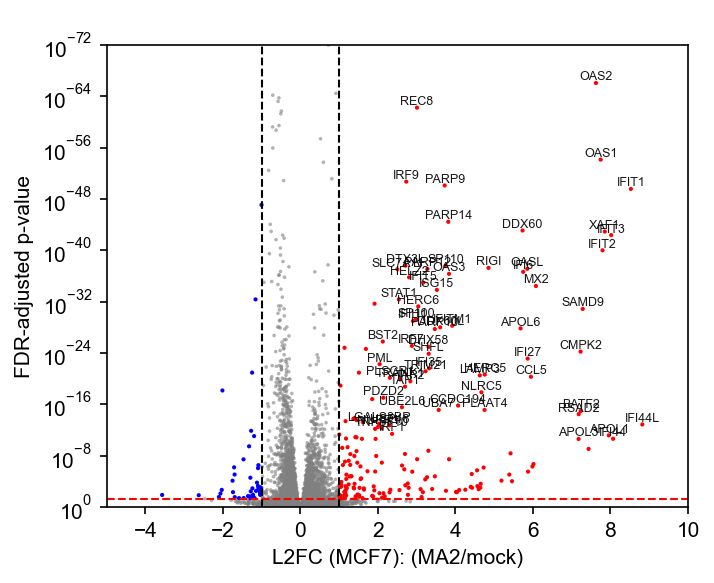

In [7]:
l2fc_cutoff=1
print("L2FC cutoff: "+str(l2fc_cutoff))
genenames_data = genenames_MCF7

MA2_up_MCF7 = (MA2_vs_mock_MCF7[2][:,1] > l2fc_cutoff) & (MA2_vs_mock_MCF7[2][:,5] < 0.05) & (~low_expr_mask_MCF7)
MA2_down_MCF7 = (MA2_vs_mock_MCF7[2][:,1] < -l2fc_cutoff) & (MA2_vs_mock_MCF7[2][:,5] < 0.05) & (~low_expr_mask_MCF7)
print("Num sig upregulated genes: "+str(np.sum(MA2_up_MCF7))+".  Num sig downregulated genes: "+str(np.sum(MA2_down_MCF7)))

#make font editable
mpl.rcParams['svg.fonttype']='none' #This is the key line for making SVG text editable
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(5,4),dpi=150)

subplots_titles = [' ']
datasets_names = ['(MA2/mock)']
l2fc_datasets = [MA2_vs_mock_MCF7[2][:,1]]
padj_datasets = [MA2_vs_mock_MCF7[2][:,5]]

axs=[ax]

for i in range(len(axs)):
    fc_datasetlabel = datasets_names[i]
    l2fc_dataset = l2fc_datasets[i]
    padjs = padj_datasets[i]
    print(l2fc_dataset.shape)
    
    axs[i].scatter(l2fc_dataset[(~(MA2_up_MCF7|MA2_down_MCF7))&(~low_expr_mask_MCF7)], 
                   padjs[(~(MA2_up_MCF7|MA2_down_MCF7))&(~low_expr_mask_MCF7)], s=3, alpha=0.6, color='grey', 
                   edgecolor='none') #rasterized=True allows it to be flattened during SVG
    axs[i].scatter(l2fc_dataset[MA2_up_MCF7], padjs[MA2_up_MCF7], s=4, alpha=1, color='red', edgecolor='none')
    axs[i].scatter(l2fc_dataset[MA2_down_MCF7], padjs[MA2_down_MCF7], s=4, alpha=1, color='blue', edgecolor='none')

    for gene in np.where(MA2_up_MCF7)[0]:
        txt_color = 'black'
        alphaval = 0.9
        if l2fc_dataset[gene]>2 and padjs[gene]<1e-10:
            if padjs[gene] < 1e-250:
                print(genenames_data[:,1][gene], padjs[gene], np.log10(padjs[gene]))
                axs[i].text(l2fc_dataset[gene], 1e-251, genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
            else:
                axs[i].text(l2fc_dataset[gene], padjs[gene], genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
     
    axs[i].set_xlim(-5, 10)
    axs[i].set_ylim(1, 1e-72)
    axs[i].axhline(0.05, color='red', linestyle='--', linewidth=1)
    #axs[i].text(2.9, 0.048, 'p=0.05', color='red', horizontalalignment='right')
    axs[i].axvline(l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].axvline(-l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].semilogy()
    axs[i].set_title(subplots_titles[i])
    axs[i].set_xlabel('L2FC (MCF7): '+datasets_names[i])
    #axs[i].legend(loc='upper right', fancybox=False)

axs[0].set_ylabel('FDR-adjusted p-value')

#Now save as svg
plt.savefig("output_figures/Fig_FBS2-MCF7-quadruplicate-MA2up-RNAseq-Volcano_LabelCutoffL2fc2-pval1e-10.svg")


In [8]:
MA2up_file = open("output_files/MA2up_MCF7_FBS2_quadruplicate.txt","w")
MA2up_file.write("Names of all genes whose L2FC>"+str(l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(MA2_up_MCF7)[0]:
    MA2up_file.write(genenames_data[:,1][gene]+'\n')
MA2up_file.close()

MA2down_file = open("output_files/MA2down_MCF7_FBS2_quadruplicate.txt","w")
MA2down_file.write("Names of all genes whose L2FC<"+str(-l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(MA2_down_MCF7)[0]:
    MA2down_file.write(genenames_data[:,1][gene]+'\n')
MA2down_file.close()

### 3. Plot expression heatmaps

In [9]:
#Color scale=Normalized against mock average: for each sample, divide by mock avg. Finally, take the log2 of all conditions

mock_avg_MCF7 = np.mean(MCF7_matrix[:, :4],axis=1, keepdims=True)
#Divide each element by mock avg
l2fc_mockavg_norm_MCF7 = np.log2((MCF7_matrix+0.1) / (mock_avg_MCF7+0.1))


(20053,)
82
3


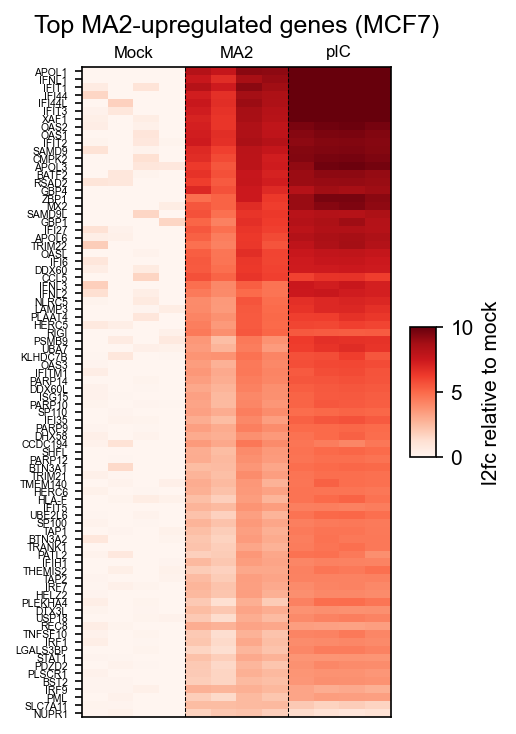

In [10]:
#MCF7 heatmap without diABZI
#Plot heatmap of the genes that are up in MA2

MA2_up_MCF7_l2fc2 = (MA2_vs_mock_MCF7[2][:,1] > 2) & (MA2_vs_mock_MCF7[2][:,5] < 1e-5)

fig, ax = plt.subplots(figsize=(3.5,5),dpi=150)

matrix = l2fc_mockavg_norm_MCF7[:,:]
filt = MA2_up_MCF7_l2fc2

plt.axvline(4-0.5, color='black', linestyle='--', linewidth=0.5) 
plt.axvline(8-0.5, color='black', linestyle='--', linewidth=0.5) 
plt.axvline(12-0.5, color='black', linestyle='--', linewidth=0.5) 

#sort by treatment average expression
avg_RNAseq_MA2 = np.average(matrix[:, 4:], axis=1)
print(avg_RNAseq_MA2.shape)
idx_WTRNA = np.argsort(-avg_RNAseq_MA2[filt])
im=ax.imshow(matrix[filt][idx_WTRNA], aspect="auto", cmap='Reds', vmin=0, vmax=10,
             interpolation="none")
ax.set_title('Top MA2-upregulated genes (MCF7)')

# Set row labels
row_labels = genenames_MCF7[:,1][filt][idx_WTRNA]
#for ele in row_labels:
    #print(ele)
print(len(row_labels))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=5)

col_labels = ['Mock','MA2','pIC']
#for ele in row_labels:
    #print(ele)
print(len(col_labels))
ax.set_xticks(4*np.arange(len(col_labels))+1.5)
ax.set_xticklabels(col_labels, fontsize=8)

# Move col labels to the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis='x', which='both', length=0)

cbar = plt.colorbar(im, ax=ax, shrink=0.2, aspect=5, label='l2fc relative to mock')
fig.tight_layout()

plt.savefig("output_figures/Fig_FBS2-MCF7_MA2up-vs-pIC_L2FC2_padj1e-5_RNAseq-Heatmap.svg")


In [11]:
print("Finished running successfully.")

Finished running successfully.
